# 1. Environment Setup

In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)


TensorFlow: 2.21.0
PyTorch: 2.14.0+cpu


In [8]:
train_df = pd.read_csv(os.path.join("fashion-mnist_train.csv"))
test_df  = pd.read_csv(os.path.join("fashion-mnist_test.csv"))

X_all = train_df.drop(columns=["label"]).values.astype(np.float32) / 255.0  
y_all = train_df["label"].values.astype(np.int64)

X_test = test_df.drop(columns=["label"]).values.astype(np.float32) / 255.0  
y_test = test_df["label"].values.astype(np.int64)

# 80 20 train split
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Train samples:      {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")

Train samples:      48000
Validation samples: 12000
Test samples:       10000


         class  train   val  test
0  T-shirt/top   4800  1200  1000
1      Trouser   4800  1200  1000
2     Pullover   4800  1200  1000
3        Dress   4800  1200  1000
4         Coat   4800  1200  1000
5       Sandal   4800  1200  1000
6        Shirt   4800  1200  1000
7      Sneaker   4800  1200  1000
8          Bag   4800  1200  1000
9   Ankle boot   4800  1200  1000


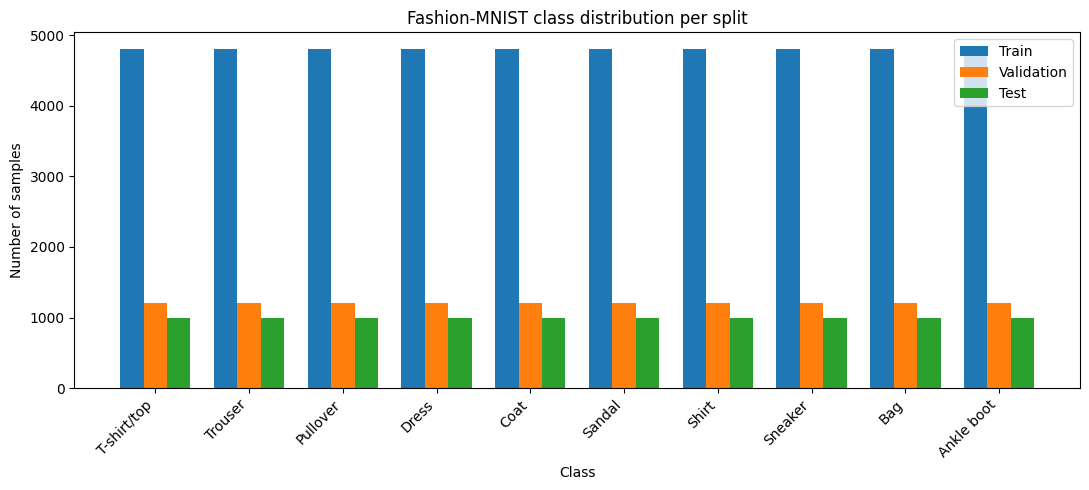

In [9]:
# Class distribution in each split
def class_counts(y):
    return np.bincount(y, minlength=10)

counts_train = class_counts(y_train)
counts_val = class_counts(y_val)
counts_test = class_counts(y_test)

dist_df = pd.DataFrame({'class': CLASS_NAMES, 'train': counts_train, 'val': counts_val, 'test': counts_test})
print(dist_df)

x = np.arange(10)
width = 0.25
plt.figure(figsize=(11, 5))
plt.bar(x - width, counts_train, width, label='Train')
plt.bar(x, counts_val, width, label='Validation')
plt.bar(x + width, counts_test, width, label='Test')
plt.xticks(x, CLASS_NAMES, rotation=45, ha='right')
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Fashion-MNIST class distribution per split')
plt.legend()
plt.tight_layout()
plt.show()


# Part 1: Backpropagation From Scratch

In [10]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(z.dtype)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_onehot):
    m = probs.shape[0]
    return -np.sum(y_onehot * np.log(probs + 1e-9)) / m


class TwoLayerMLP:
    """784 then go to hidden (ReLU) and then to 10 (softmax), trained with plain gradient descent."""

    def __init__(self, n_in=784, n_hidden=64, n_out=10, seed=SEED):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2.0 / n_in)
        self.b1 = np.zeros((1, n_hidden))

        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2.0 / n_hidden)
        self.b2 = np.zeros((1, n_out))

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2

    def backward(self, X, y_onehot):
        m = X.shape[0]

        dZ2 = (self.A2 - y_onehot) / m

        dW2 = np.dot(self.A1.T, dZ2)
        db2 = dZ2.sum(axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)

        dZ1 = dA1 * relu_deriv(self.Z1)

        dW1 = np.dot(X.T, dZ1)
        db1 = dZ1.sum(axis=0, keepdims=True)

        return dW1, db1, dW2, db2

    def step(self, grads, lr):
        dW1, db1, dW2, db2 = grads

        self.W1 -= lr * dW1
        self.b1 -= lr * db1

        self.W2 -= lr * dW2
        self.b2 -= lr * db2

Epoch  1/20 - loss: 2.6597
Epoch  2/20 - loss: 2.2237
Epoch  3/20 - loss: 2.1062
Epoch  4/20 - loss: 2.0662
Epoch  5/20 - loss: 1.9607
Epoch  6/20 - loss: 1.7510
Epoch  7/20 - loss: 1.6147
Epoch  8/20 - loss: 1.5727
Epoch  9/20 - loss: 1.4349
Epoch 10/20 - loss: 1.4415
Epoch 11/20 - loss: 1.2720
Epoch 12/20 - loss: 1.2187
Epoch 13/20 - loss: 1.1775
Epoch 14/20 - loss: 1.1692
Epoch 15/20 - loss: 1.1673
Epoch 16/20 - loss: 1.1511
Epoch 17/20 - loss: 1.1380
Epoch 18/20 - loss: 1.0926
Epoch 19/20 - loss: 1.0457
Epoch 20/20 - loss: 1.0105


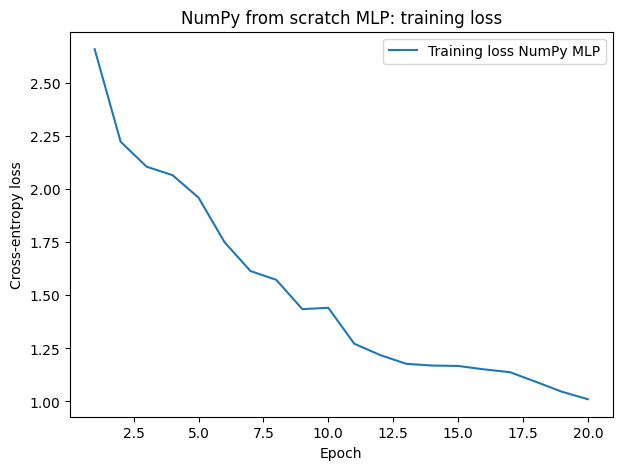

In [11]:
# Train 
subset_idx = np.random.RandomState(SEED).choice(len(X_train), size=5000, replace=False)
X_sub = X_train[subset_idx]
y_sub = y_train[subset_idx]
Y_sub_onehot = to_categorical(y_sub, num_classes=10)

net = TwoLayerMLP(n_in=784, n_hidden=64, n_out=10, seed=SEED)

LR = 0.2
EPOCHS_SCRATCH = 20
train_losses = []

for epoch in range(EPOCHS_SCRATCH):
    probs = net.forward(X_sub)
    loss = cross_entropy_loss(probs, Y_sub_onehot)
    grads = net.backward(X_sub, Y_sub_onehot)
    net.step(grads, LR)
    train_losses.append(loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS_SCRATCH} - loss: {loss:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_SCRATCH + 1), train_losses, label='Training loss NumPy MLP')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('NumPy from scratch MLP: training loss')
plt.legend()
plt.show()


In [14]:

net_check = TwoLayerMLP(n_in=784, n_hidden=64, n_out=10, seed=SEED)

batch_X = X_sub[:128]
batch_y = y_sub[:128]
batch_Y_onehot = to_categorical(batch_y, num_classes=10)

probs = net_check.forward(batch_X)
numpy_grads = net_check.backward(batch_X, batch_Y_onehot)
dW1_np, db1_np, dW2_np, db2_np = numpy_grads

class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

torch_net = TorchMLP()
with torch.no_grad():
    torch_net.fc1.weight.copy_(torch.tensor(net_check.W1.T, dtype=torch.float32))
    torch_net.fc1.bias.copy_(torch.tensor(net_check.b1.flatten(), dtype=torch.float32))
    torch_net.fc2.weight.copy_(torch.tensor(net_check.W2.T, dtype=torch.float32))
    torch_net.fc2.bias.copy_(torch.tensor(net_check.b2.flatten(), dtype=torch.float32))

Xt = torch.tensor(batch_X, dtype=torch.float32)
yt = torch.tensor(batch_y, dtype=torch.long)

logits = torch_net(Xt)
criterion = nn.CrossEntropyLoss()          
loss = criterion(logits, yt)
torch_net.zero_grad()
loss.backward()

dW1_pt = torch_net.fc1.weight.grad.numpy().T
db1_pt = torch_net.fc1.bias.grad.numpy().reshape(1, -1)
dW2_pt = torch_net.fc2.weight.grad.numpy().T
db2_pt = torch_net.fc2.bias.grad.numpy().reshape(1, -1)

print("Max abs diff dW1:", np.max(np.abs(dW1_np - dW1_pt)))
print("Max abs diff db1:", np.max(np.abs(db1_np - db1_pt)))
print("Max abs diff dW2:", np.max(np.abs(dW2_np - dW2_pt)))
print("Max abs diff db2:", np.max(np.abs(db2_np - db2_pt)))


Max abs diff dW1: 2.8710769095496858e-08
Max abs diff db1: 7.014329436727529e-09
Max abs diff dW2: 1.7697958015761017e-08
Max abs diff db2: 6.23331934332394e-09


# Gradient Verification
For gradient verification,we implemented the same network in PyTorch using the same initial weights 
and the same batch of data then we compared the gradients calculated manually in NumPy with the gradients calculated by PyTorch.
The maximum absolute differences were:
* **dW1:** 2.8710769095496858e-08
* **db1:** 7.014329436727529e-09
* **dW2:** 1.7697958015761017e-08
* **db2:** 6.23331934332394e-09

The differences are very small and close to zero. This shows that the gradients calculated manually in NumPy are almost the 
same as the PyTorch gradients. Therefore, my forward and backward propagation implementation is correct.


# Part 2: Baseline Model and Activation Study

In [15]:
HIDDEN_UNITS = (128, 64)
EPOCHS_P2 = 15
BATCH_SIZE = 128

Y_train_oh = to_categorical(y_train, 10)
Y_val_oh = to_categorical(y_val, 10)
Y_test_oh = to_categorical(y_test, 10)

def make_hidden_activation(name):
    if name == 'leaky_relu':
        return LeakyReLU(alpha=0.01)
    return name

def build_baseline(activation_name):
    tf.random.set_seed(SEED)  
    act = make_hidden_activation(activation_name)
    model = Sequential([
        Dense(HIDDEN_UNITS[0], activation=act, input_shape=(784,), name='hidden1'),
        Dense(HIDDEN_UNITS[1], activation=act, name='hidden2'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [16]:
activations = ['sigmoid', 'tanh', 'relu', 'leaky_relu']
histories = {}
models = {}

for act in activations:
    print(f"\nTraining with hidden activation = {act}")
    m = build_baseline(act)
    h = m.fit(X_train, Y_train_oh, validation_data=(X_val, Y_val_oh),
              epochs=EPOCHS_P2, batch_size=BATCH_SIZE, verbose=0)
    histories[act] = h
    models[act] = m
    print(f"  final val_loss={h.history['val_loss'][-1]:.4f}  val_accuracy={h.history['val_accuracy'][-1]:.4f}")



Training with hidden activation = sigmoid


C:\Users\HTAT\ds_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  final val_loss=0.3339  val_accuracy=0.8737

Training with hidden activation = tanh
  final val_loss=0.3527  val_accuracy=0.8748

Training with hidden activation = relu
  final val_loss=0.3789  val_accuracy=0.8694

Training with hidden activation = leaky_relu


C:\Users\HTAT\ds_env\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


  final val_loss=0.3918  val_accuracy=0.8609


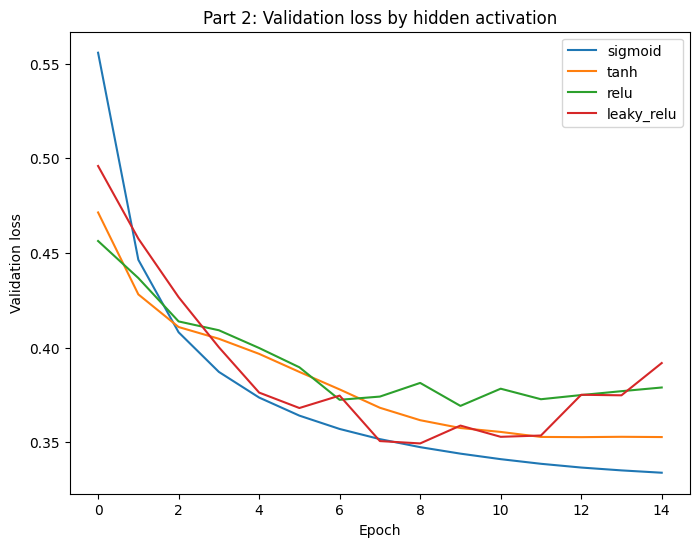

In [17]:
plt.figure(figsize=(8, 6))
for act in activations:
    plt.plot(histories[act].history['val_loss'], label=act)
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('Part 2: Validation loss by hidden activation')
plt.legend()
plt.show()


In [20]:
def first_layer_grad_mean_abs(model, X_batch, Y_batch_oh):
    X_t = tf.convert_to_tensor(X_batch, dtype=tf.float32)
    Y_t = tf.convert_to_tensor(Y_batch_oh, dtype=tf.float32)
    with tf.GradientTape() as tape:
        preds = model(X_t, training=True)
        loss = tf.keras.losses.categorical_crossentropy(Y_t, preds)
        loss = tf.reduce_mean(loss)
    kernel = model.get_layer('hidden1').kernel
    grad = tape.gradient(loss, kernel)
    return float(tf.reduce_mean(tf.abs(grad)))

val_batch_X = X_val[:256]
val_batch_Y = Y_val_oh[:256]
aa
grad_report = {}
for act in ['sigmoid', 'relu']:
    m_epoch1 = build_baseline(act)
    m_epoch1.fit(X_train, Y_train_oh, epochs=1, batch_size=BATCH_SIZE, verbose=0)
    g1 = first_layer_grad_mean_abs(m_epoch1, val_batch_X, val_batch_Y)

    g_final = first_layer_grad_mean_abs(models[act], val_batch_X, val_batch_Y)

    grad_report[act] = (g1, g_final)
    print(f"{act:8s} | mean|grad| epoch 1: {g1:.3e}  |  mean|grad| final epoch: {g_final:.3e}")


sigmoid  | mean|grad| epoch 1: 1.748e-04  |  mean|grad| final epoch: 5.645e-04
relu     | mean|grad| epoch 1: 1.208e-03  |  mean|grad| final epoch: 1.901e-03


In [23]:
relu_model = models['relu']
hidden_layer = relu_model.get_layer('hidden1')
activations_batch = hidden_layer(val_batch_X)
activations_batch = activations_batch.numpy()
dead_units = np.all(activations_batch == 0, axis=0)
dead_pct = 100 * dead_units.sum() / dead_units.shape[0]
print(f"Dead ReLU units in hidden1: {dead_units.sum()} / {dead_units.shape[0]} ({dead_pct:.2f}%)")

Dead ReLU units in hidden1: 3 / 128 (2.34%)


# Vanishing Gradients:
The sigmoid model has a much smaller mean absolute gradient than ReLU at both epoch 1 and the 
final epoch, which shows that sigmoid gradients are weaker and can lead to vanishing gradients. 
ReLU maintains larger gradients in the first hidden layer, so it is less affected by the vanishing-gradient problem.

# Dead ReLU Units:
In the ReLU model, 3 out of 128 hidden units produced zero output for every sample in the validation batch, 
which is **2.34%** dead units. This shows that a small number of ReLU neurons became inactive for the whole batch, 
but the percentage is low in this experiment.


# Part 3: Loss Functions

In [24]:
EPOCHS_P3 = 15

model_ce = build_baseline('relu')
model_ce.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_ce = model_ce.fit(X_train, Y_train_oh, validation_data=(X_val, Y_val_oh),
                        epochs=EPOCHS_P3, batch_size=BATCH_SIZE, verbose=0)
test_loss_ce, test_acc_ce = model_ce.evaluate(X_test, Y_test_oh, verbose=0)

model_mse = build_baseline('relu')
model_mse.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])
hist_mse = model_mse.fit(X_train, Y_train_oh, validation_data=(X_val, Y_val_oh),
                          epochs=EPOCHS_P3, batch_size=BATCH_SIZE, verbose=0)
test_loss_mse, test_acc_mse = model_mse.evaluate(X_test, Y_test_oh, verbose=0)

print(f"Cross-entropy model: test accuracy: {test_acc_ce:.4f}")
print(f"MSE model: test accuracy: {test_acc_mse:.4f}")


Cross-entropy model: test accuracy: 0.8711
MSE model: test accuracy: 0.8796


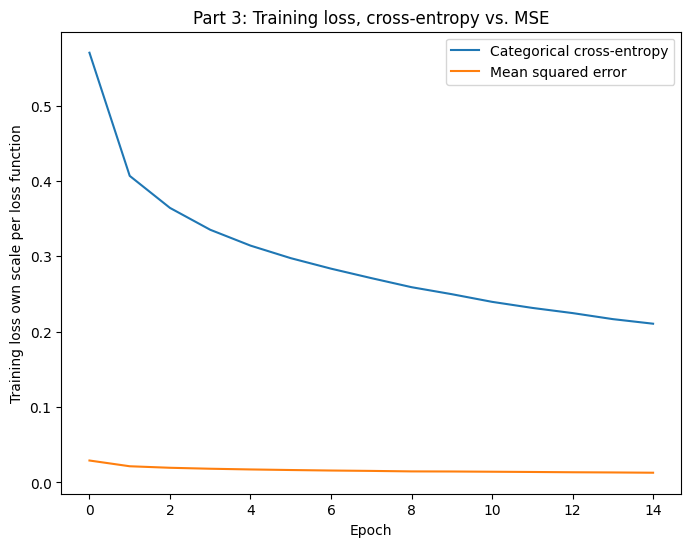

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(hist_ce.history['loss'], label='Categorical cross-entropy')
plt.plot(hist_mse.history['loss'], label='Mean squared error')
plt.xlabel('Epoch')
plt.ylabel('Training loss own scale per loss function')
plt.title('Part 3: Training loss, cross-entropy vs. MSE')
plt.legend()
plt.show()


C:\Users\HTAT\ds_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test MSE:  2920.90
Test RMSE: 54.05
Test MAE:  42.76


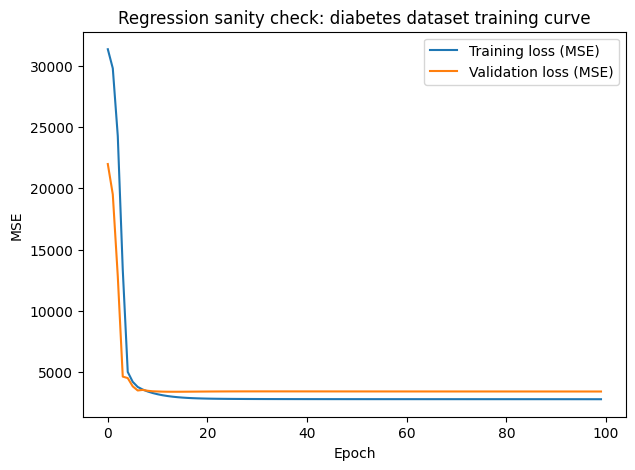

In [28]:
diabetes = load_diabetes()
Xd, yd = diabetes.data, diabetes.target

Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, random_state=SEED)

reg_model = Sequential([
    Dense(32, activation='relu', input_shape=(Xd_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1)  
])
reg_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
reg_history = reg_model.fit(Xd_train, yd_train, validation_split=0.2, epochs=100, batch_size=16, verbose=0)

yd_pred = reg_model.predict(Xd_test, verbose=0).flatten()
mse = mean_squared_error(yd_test, yd_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(yd_test, yd_pred)

print(f"Test MSE:  {mse:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE:  {mae:.2f}")

plt.figure(figsize=(7, 5))
plt.plot(reg_history.history['loss'], label='Training loss (MSE)')
plt.plot(reg_history.history['val_loss'], label='Validation loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Regression sanity check: diabetes dataset training curve')
plt.legend()
plt.show()


Cross-entropy converges faster here because its gradient with respect to the softmax logits is simply predicted probability: true label, 
so it remains meaningful when the model is confidently wrong. With MSE, this error is also multiplied by the softmax derivative, 
which can become very small when the output is close to 0 or 1, resulting in smaller gradients and slower learning.
